<a href="https://colab.research.google.com/github/SergeiVKalinin/automated-experiment-book/blob/main/chapters/02_grid_krr_three_gaussians_1d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Open this notebook in Google Colab](https://colab.research.google.com/github/SergeiVKalinin/automated-experiment-book/blob/main/chapters/02_grid_krr_three_gaussians_1d.ipynb)  
[View notebook source on GitHub](https://github.com/SergeiVKalinin/automated-experiment-book/blob/main/chapters/02_grid_krr_three_gaussians_1d.ipynb)

May 18, 2026, Sergei V. Kalinin

# Grid exploration of a 1D unknown function

In this notebook, we explore an unknown one-dimensional function using a regular grid of measurements.

The hidden function is constructed from three Gaussian peaks. We assume that the measurements are noiseless. After measuring the function on a finite grid, we interpolate the response using kernel ridge regression with an RBF kernel.

This is the simplest possible experimental strategy:

1. Define a one-dimensional experimental domain.
2. Measure the function on a regular grid.
3. Fit a surrogate model to the measured data.
4. Use the surrogate to interpolate the function between measured points.
5. Compare the reconstructed function to the true hidden function.

In [3]:
#| label: grid-krr-1d-imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Domain
x_min, x_max = 0.0, 1.0

# Measurement grid
n_grid = 15

# Fine grid for plotting and evaluation
n_plot = 500

# KRR parameters
krr_alpha = 1e-8          # very small regularization because measurements are noiseless
krr_length_scale = 0.06   # RBF kernel length scale
krr_gamma = 1.0 / (2.0 * krr_length_scale**2)

print("Experimental domain:")
print(f"x in [{x_min}, {x_max}]")

print("\nMeasurement grid:")
print(f"{n_grid} measurements")

print("\nKRR parameters:")
print(f"alpha = {krr_alpha}")
print(f"length scale = {krr_length_scale}")
print(f"gamma = {krr_gamma}")

Experimental domain:
x in [0.0, 1.0]

Measurement grid:
15 measurements

KRR parameters:
alpha = 1e-08
length scale = 0.06
gamma = 138.88888888888889


In [4]:
#| label: three-gaussian-function-1d

gaussian_parameters = pd.DataFrame(
    [
        {"component": 1, "amplitude": 1.00, "x0": 0.22, "sigma": 0.045},
        {"component": 2, "amplitude": 0.75, "x0": 0.52, "sigma": 0.080},
        {"component": 3, "amplitude": 0.90, "x0": 0.78, "sigma": 0.055},
    ]
)

display(gaussian_parameters)


def gaussian_1d(x, amplitude, x0, sigma):
    """A one-dimensional Gaussian."""
    return amplitude * np.exp(
        -0.5 * ((x - x0) / sigma) ** 2
    )


def hidden_function(x):
    """
    Hidden function f(x), represented as a sum of three Gaussian components.

    x can be a scalar or a NumPy array.
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    for _, row in gaussian_parameters.iterrows():
        y += gaussian_1d(
            x,
            row["amplitude"],
            row["x0"],
            row["sigma"],
        )

    return y

,component,amplitude,x0,sigma
0,1,1.00,0.22,0.045
1,2,0.75,0.52,0.080
2,3,0.90,0.78,0.055


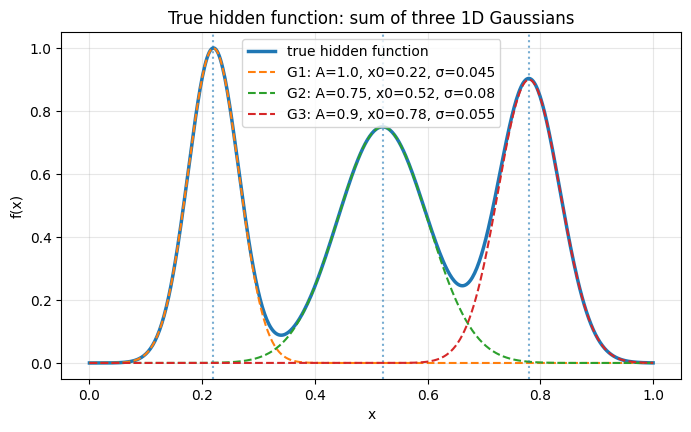

In [5]:
#| label: fig-true-three-gaussian-function-1d
#| fig-cap: "The true one-dimensional hidden function constructed from three Gaussian components."

x_plot = np.linspace(x_min, x_max, n_plot)
y_true = hidden_function(x_plot)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x_plot, y_true, linewidth=2.5, label="true hidden function")

for _, row in gaussian_parameters.iterrows():
    y_component = gaussian_1d(
        x_plot,
        row["amplitude"],
        row["x0"],
        row["sigma"],
    )

    ax.plot(
        x_plot,
        y_component,
        linestyle="--",
        label=(
            f"G{int(row['component'])}: "
            f"A={row['amplitude']}, "
            f"x0={row['x0']}, "
            f"σ={row['sigma']}"
        ),
    )

    ax.axvline(row["x0"], linestyle=":", alpha=0.6)

ax.set_title("True hidden function: sum of three 1D Gaussians")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [6]:
#| label: noiseless-grid-measurements-1d

x_measured = np.linspace(x_min, x_max, n_grid)

# Noiseless measurements
y_measured = hidden_function(x_measured)

measurements = pd.DataFrame(
    {
        "x": x_measured,
        "measured_value": y_measured,
    }
)

display(measurements)

print(f"Total number of measurements: {len(measurements)}")

,x,measured_value
0,0.000000,0.000006
1,0.071429,0.004295
2,0.142857,0.230077
3,0.214286,0.992476
4,0.285714,0.354589
5,0.357143,0.104063
6,0.428571,0.390359
7,0.500000,0.726927
8,0.571429,0.610667
9,0.642857,0.270831


Total number of measurements: 15


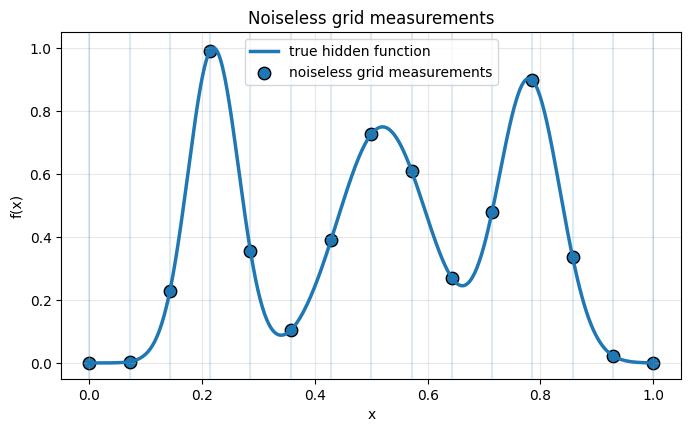

In [7]:
#| label: fig-measurement-grid-1d
#| fig-cap: "Regular grid measurements of the one-dimensional hidden function. Measurements are assumed noiseless."

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x_plot, y_true, linewidth=2.5, label="true hidden function")
ax.scatter(
    x_measured,
    y_measured,
    s=80,
    edgecolor="black",
    label="noiseless grid measurements",
)

for x_value in x_measured:
    ax.axvline(x_value, alpha=0.15)

ax.set_title("Noiseless grid measurements")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [8]:
#| label: krr-fit-1d

X_measured = x_measured.reshape(-1, 1)
X_plot = x_plot.reshape(-1, 1)

krr_model = KernelRidge(
    kernel="rbf",
    alpha=krr_alpha,
    gamma=krr_gamma,
)

krr_model.fit(X_measured, y_measured)

y_krr = krr_model.predict(X_plot)
y_pred_at_measured = krr_model.predict(X_measured)

train_rmse = np.sqrt(mean_squared_error(y_measured, y_pred_at_measured))
train_mae = mean_absolute_error(y_measured, y_pred_at_measured)

print("KRR fit quality at measured grid points:")
print(f"RMSE = {train_rmse:.3e}")
print(f"MAE  = {train_mae:.3e}")

KRR fit quality at measured grid points:
RMSE = 5.290e-09
MAE  = 3.505e-09


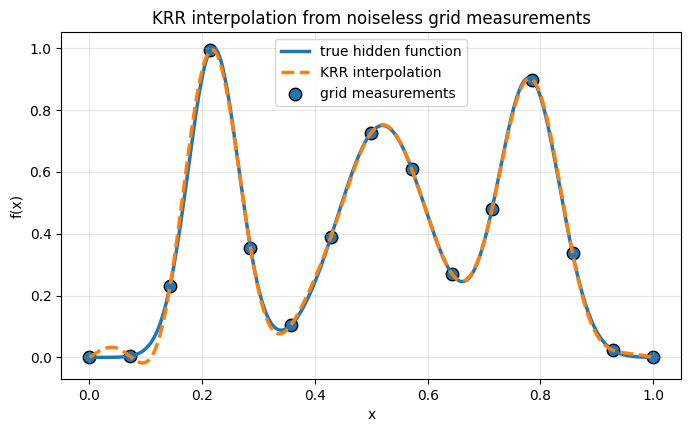

In [9]:
#| label: fig-krr-reconstruction-1d
#| fig-cap: "KRR interpolation of the one-dimensional hidden function from noiseless grid measurements."

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x_plot, y_true, linewidth=2.5, label="true hidden function")
ax.plot(x_plot, y_krr, linestyle="--", linewidth=2.5, label="KRR interpolation")
ax.scatter(
    x_measured,
    y_measured,
    s=80,
    edgecolor="black",
    label="grid measurements",
)

ax.set_title("KRR interpolation from noiseless grid measurements")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

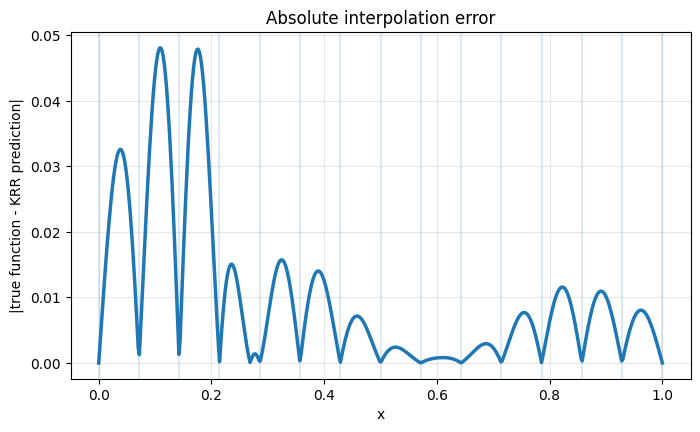

In [10]:
#| label: fig-krr-error-1d
#| fig-cap: "Absolute interpolation error between the true hidden function and the KRR reconstruction."

absolute_error = np.abs(y_true - y_krr)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x_plot, absolute_error, linewidth=2.5)

for x_value in x_measured:
    ax.axvline(x_value, alpha=0.15)

ax.set_title("Absolute interpolation error")
ax.set_xlabel("x")
ax.set_ylabel("|true function - KRR prediction|")
ax.grid(True, alpha=0.3)

plt.show()

In [11]:
#| label: krr-reconstruction-metrics-1d

fine_grid_rmse = np.sqrt(mean_squared_error(y_true, y_krr))
fine_grid_mae = mean_absolute_error(y_true, y_krr)
fine_grid_max_error = np.max(np.abs(y_true - y_krr))

metrics = pd.DataFrame(
    [
        {"metric": "RMSE on measured grid", "value": train_rmse},
        {"metric": "MAE on measured grid", "value": train_mae},
        {"metric": "RMSE on fine grid", "value": fine_grid_rmse},
        {"metric": "MAE on fine grid", "value": fine_grid_mae},
        {"metric": "Max absolute error on fine grid", "value": fine_grid_max_error},
    ]
)

display(metrics)

,metric,value
0,RMSE on measured grid,5.289930e-09
1,MAE on measured grid,3.505377e-09
2,RMSE on fine grid,1.530086e-02
3,MAE on fine grid,9.864707e-03
4,Max absolute error on fine grid,4.808504e-02


,parameter,value
0,x_min,0.000000e+00
1,x_max,1.000000e+00
2,n_grid,1.500000e+01
3,n_plot,5.000000e+02
4,krr_alpha,1.000000e-08
5,krr_length_scale,6.000000e-02
6,krr_gamma,1.388889e+02


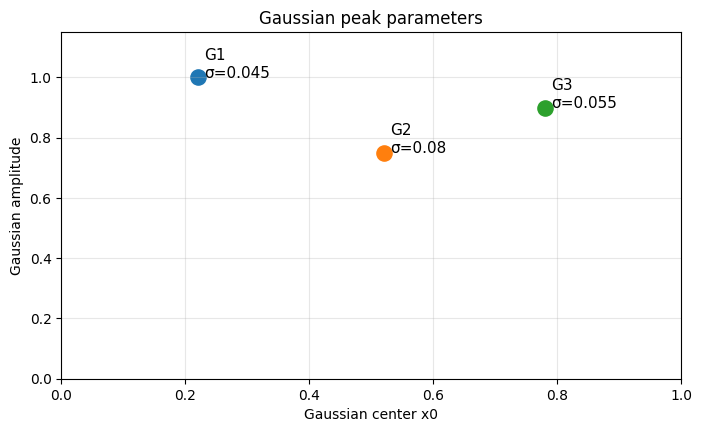

In [12]:
#| label: fig-grid-krr-parameters-1d
#| fig-cap: "Summary of the Gaussian-function parameters, grid parameters, and KRR parameters used in this notebook."

parameter_summary = pd.DataFrame(
    [
        {"parameter": "x_min", "value": x_min},
        {"parameter": "x_max", "value": x_max},
        {"parameter": "n_grid", "value": n_grid},
        {"parameter": "n_plot", "value": n_plot},
        {"parameter": "krr_alpha", "value": krr_alpha},
        {"parameter": "krr_length_scale", "value": krr_length_scale},
        {"parameter": "krr_gamma", "value": krr_gamma},
    ]
)

display(parameter_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in gaussian_parameters.iterrows():
    ax.scatter(row["x0"], row["amplitude"], s=120)
    ax.text(
        row["x0"] + 0.01,
        row["amplitude"],
        f"G{int(row['component'])}\nσ={row['sigma']}",
        fontsize=11,
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(0, 1.15 * gaussian_parameters["amplitude"].max())
ax.set_title("Gaussian peak parameters")
ax.set_xlabel("Gaussian center x0")
ax.set_ylabel("Gaussian amplitude")
ax.grid(True, alpha=0.3)

plt.show()

## Interpretation

This notebook demonstrates the simplest exploration strategy: a uniform grid.

Because the measurements are noiseless, the KRR model can fit the measured points nearly exactly when the regularization parameter is very small. However, the interpolation quality between measured points depends on three things:

1. The measurement-grid density.
2. The width of the Gaussian features.
3. The RBF kernel length scale used by KRR.

The grid strategy is simple and robust, but it does not use any information from previous measurements to decide where to measure next. Therefore, it can be inefficient when the function contains localized features or when measurements are expensive.

This notebook provides the baseline. Later notebooks can replace the uniform grid with adaptive sampling, uncertainty-guided exploration, Bayesian optimization, finite-budget lookahead, or reinforcement-learning-based policies.